# Sistema de predicción de ventas.

In [187]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
import pickle


## Definición del problema.

En este caso, trabajo con un conjunto de datos de ventas, y el objetivo será estimar el ritmo de las ventas desde la creación de la empresa para los próximos meses, a fin de proveer el espacio que se necesitará para su nueva localización.

> "¿Cuál será el volumen total de ventas para los siguientes meses en el periodo de tiempo de la mudanza y posterior?".


## Recopilación de datos.

In [188]:
df = pd.read_csv("../data/raw/sales.csv")

## Análisis Descriptivo.

In [189]:
df

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
...,...,...
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214


In [190]:
df.dtypes

date      object
sales    float64
dtype: object

#### Observaciones: 
> - El conjunto de datos esta compuesto por 366 filas y dos columnas.
> - Columna `date` es de tipo objeto.
> - columna `sales` es de tipo flotante.

## Limpieza de Datos.

In [191]:
df.duplicated().sum()

np.int64(0)

In [192]:
df.isnull().sum()

date     0
sales    0
dtype: int64

In [193]:
df.nunique()

date     366
sales    366
dtype: int64

In [194]:
#Se modifico el tipo de dato.
df['date'] = pd.to_datetime(df['date'])

In [195]:
df.dtypes

date     datetime64[ns]
sales           float64
dtype: object

#### Observaciones:
> - No hay duplicados.
> - No hay valores nulos.
> - El conjunto de datos esta establecido en el periodo de un año.
> - La variable `date` ha sido modificado a dtypes=datetime64

In [196]:
#para asegurarse que el dataframe esta ordenado cronologicamente.
df = df.sort_index()

Se establece `date` como índice del DataFrame.

In [197]:
df = df.set_index("date")
df.head()

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


> - Se observa que la entrada de los datos se realiza todos los días a la misma hora.

Para el índice elimino las horas y dejo la fecha.

In [198]:
df.index = df.index.normalize()
df.head()

,sales
date,
2022-09-03,55.292157
2022-09-04,53.803211
2022-09-05,58.141693
2022-09-06,64.530899
2022-09-07,66.013633


#### Observaciones:
> - Dimensión temporal: año, mes y día.
> - El dato que se observa a lo largo del tiempo es el número de ventas (sales).

### Visualización de la serie temporal.

In [199]:
ts = df['sales']

### Descomposición de la serie temporal.

In [200]:
#Descomposición semanal, estacionalidad.
decomposition = seasonal_decompose(ts, period=7)

#Componente estacionario.
seasonal = decomposition.seasonal

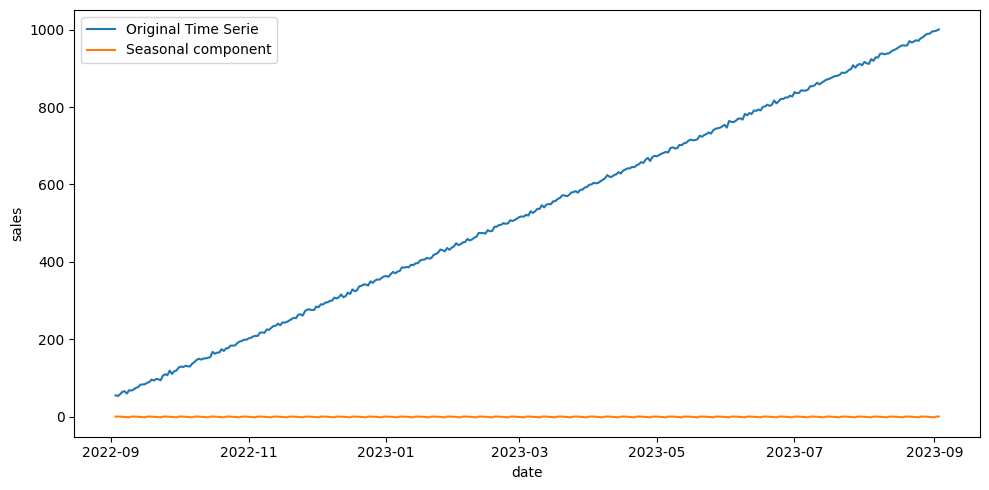

In [201]:
fig, axis = plt.subplots(figsize=(10, 5))
sns.lineplot(data=ts, label="Original Time Serie")
sns.lineplot(data=seasonal, label="Seasonal component")

plt.tight_layout()

#### Observaciones:


> Serie temporal:
> - Tensor: El tensor de la serie temporal es **diaria**, la unidad de tiempo mínima para la cual hay datos.
> - Tendencia: **ascendente**, muestra un crecimiento constante a largo plazo.
> - Estacionalidad:  **no es estacionaria**, el crecimiento aparece siempre constante sin depender de un periodo.
> - Variabilidad: hay **pequeñas fluctuaciones diarias** por encima y por debajo de la línea de tendencia, sin cambios bruscos.
> - Ruidos: **No** presenta ruidos.


Prueba de estacionariedad.

In [202]:
def test_stationarity(timeseries):
    df_test = adfuller(timeseries, autolag="AIC")
    df_output = pd.Series(df_test[0:4], index=["Test Statistic", "p-value", "Lags Used", "Number of Observations Used"])
    for key, value in df_test[4].items():
        df_output[f'Critical Value {key}'] = value
    return df_output

In [203]:
test_stationarity(ts)

Test Statistic                   0.545414
p-value                          0.986190
Lags Used                       13.000000
Number of Observations Used    352.000000
Critical Value 1%               -3.449065
Critical Value 5%               -2.869786
Critical Value 10%              -2.571163
dtype: float64

#### Observaciones:
> - El valor de p-value superior a 0.05 indica que la serie temporal **no es estacionaria.**

### Modelo ARIMA.

Para optimizar al máximo sus resultados, debemos transformar la serie en estacionaria, y como en el caso de esta serie no lo es, debemos transformarla:

In [204]:
ts_stationary = ts.diff().dropna()
ts_stationary

date
2022-09-04   -1.488946
2022-09-05    4.338482
2022-09-06    6.389205
2022-09-07    1.482734
2022-09-08   -5.931768
                ...   
2023-08-30    0.518681
2023-08-31    5.386972
2023-09-01    0.827090
2023-09-02    1.535798
2023-09-03    3.132571
Freq: D, Name: sales, Length: 365, dtype: float64

Comparación de la serie inicial a su conversión como serie estacionaria.

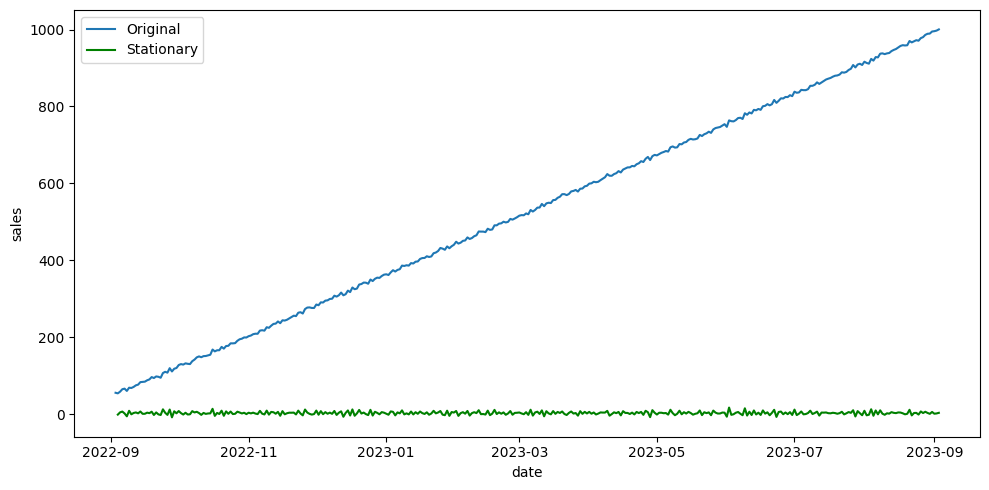

In [205]:
plt.figure(figsize=(10,5))
sns.lineplot(data=ts, label="Original")
sns.lineplot(data=ts_stationary, color="green", label="Stationary")

plt.legend()
plt.tight_layout()

Prueba de la Estacionariedad de la serie temporal

In [206]:
resultado_adf = adfuller(ts_stationary)
resultado_adf

(np.float64(-9.430263118334729),
 np.float64(5.212954111417404e-16),
 12,
 352,
 {'1%': np.float64(-3.4490648539347544),
  '5%': np.float64(-2.8697861692116478),
  '10%': np.float64(-2.5711631253228306)},
 np.float64(1758.277879882476))

**Ahora que la serie es estacionaria , p-value=5.2e-16 podemos aplicar el método ARIMA automático:**

`auto_arima`: Se encarga automáticamente de buscar los mejores parámetros para el modelo ARIMA.

In [207]:
model = auto_arima(ts_stationary, d=None, trace=True, m=7)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.58 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=2096.542, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=1966.396, Time=0.10 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=inf, Time=0.40 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=2209.657, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=1970.972, Time=0.03 sec
 ARIMA(1,0,0)(2,0,0)[7] intercept   : AIC=1968.120, Time=0.32 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AIC=1968.220, Time=0.23 sec
 ARIMA(1,0,0)(0,0,1)[7] intercept   : AIC=1966.919, Time=0.17 sec
 ARIMA(1,0,0)(2,0,1)[7] intercept   : AIC=1965.376, Time=0.66 sec
 ARIMA(1,0,0)(2,0,2)[7] intercept   : AIC=1965.211, Time=0.89 sec
 ARIMA(1,0,0)(1,0,2)[7] intercept   : AIC=1963.937, Time=0.69 sec
 ARIMA(1,0,0)(0,0,2)[7] intercept   : AIC=1967.822, Time=0.22 sec
 ARIMA(0,0,0)(1,0,2)[7] intercept   : AIC=2094.918, Time=0.52 sec
 ARIMA(2,0,0)(1,0,2)[7] intercept   : AIC=1

##### Obserciones: 
> - Orden: p=2, d=0, q=1
> - Mejor Modelo: El proceso seleccionó ARIMA(2,0,1)(1,0,2)[7] intercept.

In [208]:
#Informe estadistico
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                       SARIMAX Results                                        
==============================================================================================
Dep. Variable:                                      y   No. Observations:                  365
Model:             SARIMAX(2, 0, 1)x(1, 0, [1, 2], 7)   Log Likelihood                -910.863
Date:                                Tue, 09 Dec 2025   AIC                           1837.726
Time:                                        09:08:24   BIC                           1868.925
Sample:                                    09-04-2022   HQIC                          1850.125
                                         - 09-03-2023                                         
Covariance Type:                                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5.1892      0.477     10.869      0.000       4.253       6.125
ar.L1         -0.0774      0.054     -1.436      0.151      -0.183       0.028
ar.L2          0.0539      0.059      0.918      0.359      -0.061       0.169
ma.L1         -0.9773      0.018    -55.002      0.000      -1.012      -0.942
ar.S.L7       -0.9504      0.075    -12.606      0.000      -1.098      -0.803
ma.S.L7        1.1090      0.092     12.025      0.000       0.928       1.290
ma.S.L14       0.1809      0.054      3.358      0.001       0.075       0.286
sigma2         8.6913      0.697     12.474      0.000       7.326      10.057
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):                 0.17
Prob(Q):                              0.77   Prob(JB):                         0.92
Heteroskedasticity (H):               0.87   Skew:                             0.04
Prob(H) (two-sided):                  0.46   Kurtosis:                         2.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Split

In [209]:
#Uso 73 días para el conjunto de prueba (aprox. 20% de 365 días)
test_size = 73

#Conjunto de Entrenamiento (Primeros 293 días) - Conjunto de Prueba (Últimos 73 días)
train = ts_stationary[:-test_size]
test = ts_stationary[-test_size:]  

### Re-entrenamiento del Modelo con el conjunto de entrenamiento y la mejor parametrización.

In [210]:
#Usamos la clase ARIMA directamente: Define la estructura del modelo.
model_test = ARIMA(train, order=(2, 0, 1), seasonal_order=(1, 0, 2, 7))

#Ajustar el modelo: Entrena el modelo.
results = model_test.fit()

# results.summary() 

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [211]:
#Predicción sobre el Conjunto de Prueba.
start_pred = len(train)

end_pred = len(train) + len(test) - 1

predictions = results.predict(start=start_pred, end=end_pred)
predictions

2023-06-23   -5.677777
2023-06-24    4.991819
2023-06-25    2.133649
2023-06-26    2.664940
2023-06-27    1.847375
                ...   
2023-08-30    2.719335
2023-08-31    2.799565
2023-09-01    2.595227
2023-09-02    2.417290
2023-09-03    2.740714
Freq: D, Name: predicted_mean, Length: 73, dtype: float64

In [212]:
actual = test.values
predicted = predictions.values

metrics = {'MSE': mean_squared_error(actual, predicted),
           'RMSE': root_mean_squared_error(actual, predicted),
           'MAPE' : mean_absolute_percentage_error(actual, predicted),
           'R^2': r2_score(actual, predicted),}

metrics

{'MSE': 15.084468980668234,
 'RMSE': 3.883872935700682,
 'MAPE': 4.713359624575209,
 'R^2': 0.09070033257503662}

##### Observaciones:
> - MAPE:la predicción se desvió 15% de la venta real.
> - R²: indica que el modelo explica menos del 1% de la variabilidad total en los datos de prueba.

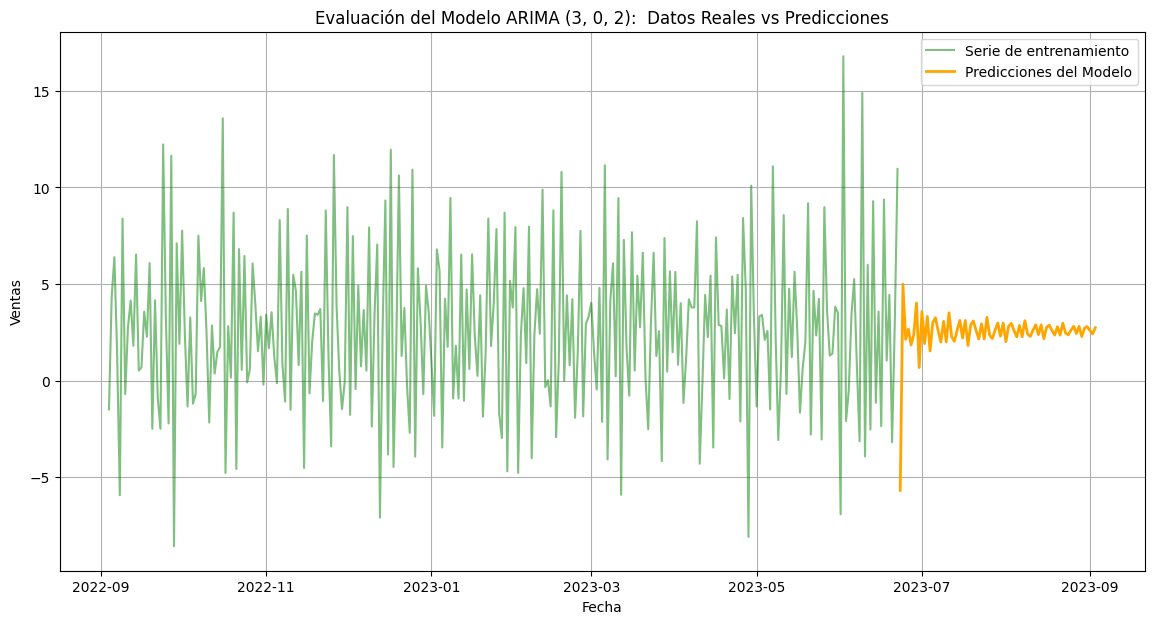

In [213]:
plt.figure(figsize=(14, 7))

sns.lineplot(data=train, label="Serie de entrenamiento", c='green', alpha=0.5)

sns.lineplot(data=predictions, label="Predicciones del Modelo", c='orange', linewidth=2)

plt.title(f'Evaluación del Modelo ARIMA (3, 0, 2):  Datos Reales vs Predicciones')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid()


##### Observaciones:
> - Los valores en el eje Y ya no son las ventas totales, sino el cambio diario neto en las ventas (diferencia).
> - Serie Estacionaria (Amarillo) - ts_stationary: Representa el cambio diario neto en las ventas (ventas de hoy menos ventas de ayer).
> - Los valores están centrados al rededor del 0 (media). Esto quiere decir que se ha eliminado la tendencia creciente de la serie original.
> - Pronóstico (Verde) - forecast: es la predicción a 12 meses generada por el modelo ARIMA.

#### Pronostico final

#### Revertimos la diferenciación para predecir en la serie original.

In [214]:
# Último valor de la serie original antes de diferenciar
last_value = ts.iloc[-1]

# Reconstruir las predicciones a partir del último valor conocido
forecast_original_scale = predictions.cumsum() + last_value

Visualización del pronostico final:

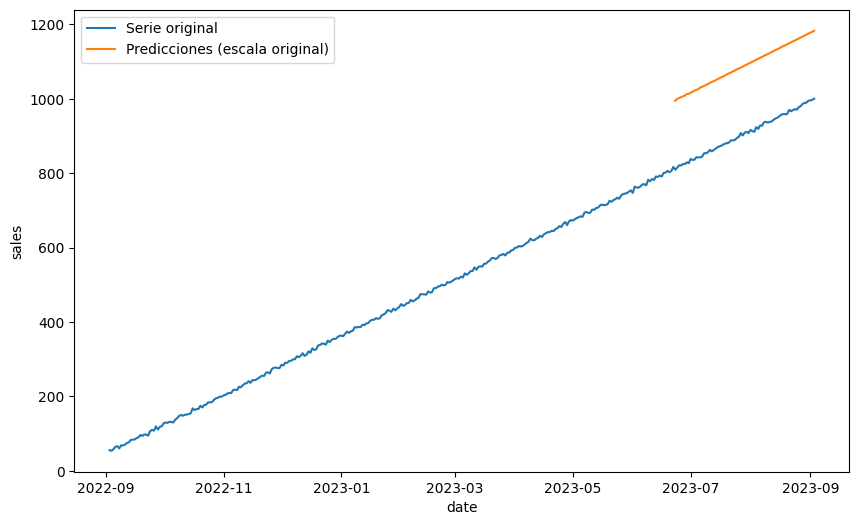

In [215]:
plt.figure(figsize=(10, 6))

# Serie original
sns.lineplot(data=ts, label="Serie original")
# Predicciones en la escala original
sns.lineplot(data=forecast_original_scale, label="Predicciones (escala original)")

plt.legend()

> "¿Cuál será el volumen total de ventas para los siguientes meses en el periodo de tiempo de la mudanza y posterior?".
**TODAVÍA NO PUEDO RESPONDER A LA PREGUNTA CON PRECISIÓN.**

### Guardar Modelo.

In [216]:
with open('../models/decision-tree-diabetes.pkl', 'wb') as file:
    pickle.dump(forecast_original_scale, file)

### Conclusiones
> - El modelo ARIMA no hace buenas predicciones, posiblemente por la conversión a estacionaría, el exceso de ruido.
> - En una de las pruebas para intentar mejorar el modelo probé hacer un suavizado a sales, pero el modelo en lugar de mejorar, empeoró.
> - Me gustaría saber cual es una buena solución a este problema.